In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    fbeta_score,
    precision_recall_curve,
    auc,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.style.use("default")
sns.set_context("notebook")

In [2]:
DATA_PATH = "modeling_dataset_v1.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (401, 23)

Columns:
['company_id', 'financial_year_end', 'label', 'operating_cf_3yr_mean', 'operating_cf_3yr_std', 'investing_cf_3yr_mean', 'investing_cf_3yr_std', 'financing_cf_3yr_mean', 'financing_cf_3yr_std', 'revenue_3yr_mean', 'revenue_3yr_std', 'profit_after_tax_3yr_mean', 'profit_after_tax_3yr_std', 'total_assets_3yr_mean', 'total_assets_3yr_std', 'total_liabilities_3yr_mean', 'total_liabilities_3yr_std', 'equity_3yr_mean', 'equity_3yr_std', 'financing_dependency_ratio', 'pct_years_ocf_negative', 'revenue_3yr_growth', 'profit_3yr_growth']


In [3]:
# Feature / Target Separation
TARGET_COL = "label"
DROP_COLS = ["company_id", "financial_year_end", TARGET_COL]

X = df.drop(columns=DROP_COLS, errors="ignore")
y = df[TARGET_COL]
years = df["financial_year_end"]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(3))


Feature matrix shape: (401, 20)
Target distribution:
label
0    0.913
1    0.087
Name: proportion, dtype: float64


In [4]:
# Time-Based Train / Validation Split
# Train: ≤ 2020
train_mask = years <= 2020

# Validation: 2021–2023
val_mask = (years >= 2021) & (years <= 2023)

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())


Train samples: 122
Validation samples: 208

Train class distribution:
label
0    111
1     11
Name: count, dtype: int64

Validation class distribution:
label
0    190
1     18
Name: count, dtype: int64


In [5]:
# Feature Scalling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [6]:
# Train Logistic Regression
model = LogisticRegression(
    class_weight="balanced",
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")


Model trained successfully.


In [7]:
# Validation Prediction
y_pred = model.predict(X_val_scaled)
y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]


In [9]:
# Evaluation
precision_risky = precision_score(y_val, y_pred, pos_label=1)
recall_risky = recall_score(y_val, y_pred, pos_label=1)
f2_score = fbeta_score(y_val, y_pred, beta=2, pos_label=1)

precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

print("=== PRIMARY METRICS (Risky Class) ===")
print(f"Recall     : {recall_risky:.3f}")
print(f"Precision  : {precision_risky:.3f}")

print("\n=== SECONDARY METRICS ===")
print(f"F2-Score   : {f2_score:.3f}")
print(f"PR-AUC     : {pr_auc:.3f}")


=== PRIMARY METRICS (Risky Class) ===
Recall     : 0.889
Precision  : 0.640

=== SECONDARY METRICS ===
F2-Score   : 0.825
PR-AUC     : 0.874


In [10]:
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       190
           1       0.64      0.89      0.74        18

    accuracy                           0.95       208
   macro avg       0.81      0.92      0.86       208
weighted avg       0.96      0.95      0.95       208



In [11]:
feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "coefficient": model.coef_[0],
        "abs_coefficient": np.abs(model.coef_[0])
    })
    .sort_values("abs_coefficient", ascending=False)
)

feature_importance.head(10)


,feature,coefficient,abs_coefficient
17,pct_years_ocf_negative,1.844529,1.844529
16,financing_dependency_ratio,1.445526,1.445526
4,financing_cf_3yr_mean,0.697571,0.697571
0,operating_cf_3yr_mean,-0.684278,0.684278
3,investing_cf_3yr_std,0.435730,0.435730
19,profit_3yr_growth,0.377042,0.377042
7,revenue_3yr_std,-0.286838,0.286838
6,revenue_3yr_mean,-0.282864,0.282864
2,investing_cf_3yr_mean,0.282239,0.282239
11,total_assets_3yr_std,0.195445,0.195445


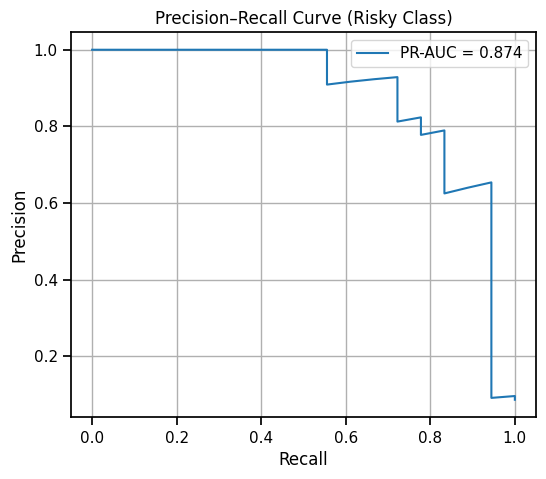

In [12]:
plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Risky Class)")
plt.legend()
plt.grid(True)
plt.show()


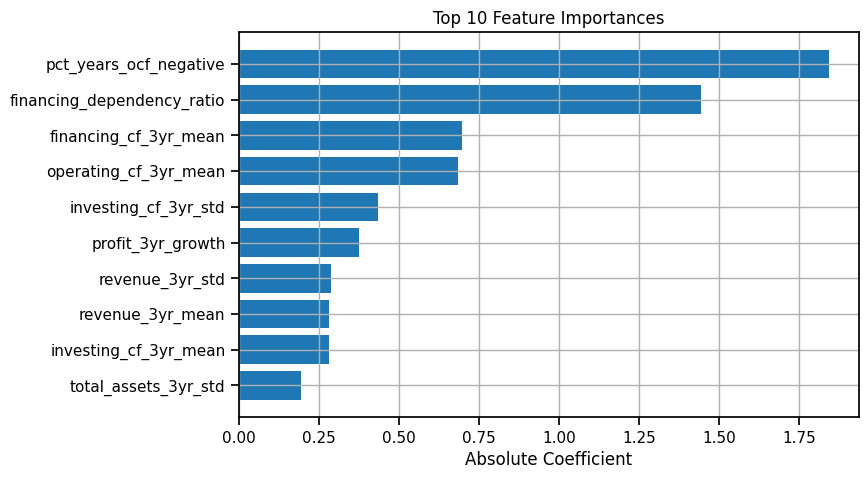

In [13]:
top_n = 10
top_features = feature_importance.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["abs_coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient")
plt.title("Top 10 Feature Importances")
plt.grid(True)
plt.show()


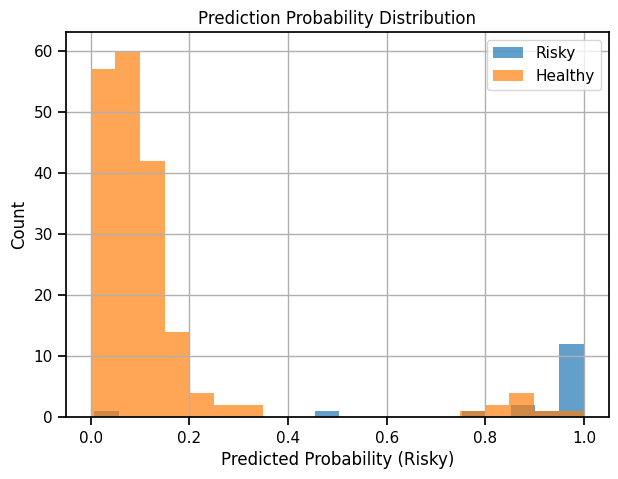

In [14]:
plt.figure(figsize=(7, 5))

plt.hist(
    y_pred_proba[y_val == 1],
    bins=20,
    alpha=0.7,
    label="Risky"
)

plt.hist(
    y_pred_proba[y_val == 0],
    bins=20,
    alpha=0.7,
    label="Healthy"
)

plt.xlabel("Predicted Probability (Risky)")
plt.ylabel("Count")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
val_results = pd.DataFrame({
    "company_id": df.loc[y_val.index, "company_id"],
    "financial_year_end": df.loc[y_val.index, "financial_year_end"],
    "true_label": y_val.values,
    "predicted_label": y_pred,
    "predicted_risk_probability": y_pred_proba
})

val_results.to_csv("logistic_regression_validation_predictions.csv", index=False)

val_results.head()


,company_id,financial_year_end,true_label,predicted_label,predicted_risk_probability
0,ABB,2021,0,0,0.198383
1,ABB,2022,0,0,0.153901
2,ABB,2023,0,0,0.138344
4,ADANIENSOL,2021,0,0,0.234824
5,ADANIENSOL,2022,0,0,0.168450
